# Software Defect Prediction using Supervised Machine Learning and Ensemble Techniques

In [1]:
from pathlib import Path
from time import perf_counter
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from threadpoolctl import threadpool_limits

warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 22
N_SPLITS = 10

RF_TREES = 30
ENSEMBLE_ESTIMATORS = 5
RF_TREES_INSIDE_ENSEMBLE = 5

np.random.seed(RANDOM_STATE)
OUTPUT_DIR = Path("sdp_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Random state:", RANDOM_STATE)
print("CV folds:", N_SPLITS)
print("RF_TREES:", RF_TREES, "| ENSEMBLE_ESTIMATORS:", ENSEMBLE_ESTIMATORS,
      "| RF_TREES_INSIDE_ENSEMBLE:", RF_TREES_INSIDE_ENSEMBLE)
print("Output directory:", OUTPUT_DIR.resolve())

Python: 3.14.3
Random state: 22
CV folds: 10
RF_TREES: 30 | ENSEMBLE_ESTIMATORS: 5 | RF_TREES_INSIDE_ENSEMBLE: 5
Output directory: /Users/tuna/Hoc/KPDL/Lab10/sdp_outputs


## 1. Nạp 10 file ARFF và kiểm tra dữ liệu

In [2]:
CANDIDATE_DIRS = [Path("."), Path("data") / "D'", Path("/mnt/data")]

DATASET_ALIASES = {
    "CM1": ["CM1.arff"],
    "JM1": ["JM1.arff", "JM1(1).arff"],
    "KC1": ["KC1.arff"],
    "MC1": ["MC1.arff", "MC1(1).arff"],
    "MC2": ["MC2.arff", "MC2(1).arff"],
    "MW1": ["MW1.arff", "MW1(1).arff"],
    "PC1": ["PC1.arff", "PC1(1).arff"],
    "PC2": ["PC2.arff", "PC2(1).arff"],
    "PC3": ["PC3.arff", "PC3(1).arff"],
    "PC4": ["PC4.arff", "PC4(1).arff"],
}

def locate_file(aliases):
    for directory in CANDIDATE_DIRS:
        for filename in aliases:
            candidate = directory / filename
            if candidate.exists():
                return candidate
    return None

DATASET_FILES = {name: locate_file(aliases) for name, aliases in DATASET_ALIASES.items()}
inventory_df = pd.DataFrame({
    "Dataset": DATASET_FILES.keys(),
    "Path": [str(p) if p else "NOT FOUND" for p in DATASET_FILES.values()],
    "Exists": [p is not None for p in DATASET_FILES.values()]
})
display(inventory_df)

missing = inventory_df.loc[~inventory_df["Exists"], "Dataset"].tolist()
assert not missing, f"Thiếu file ARFF: {missing}. Hãy đặt 10 file cạnh notebook hoặc trong data/D'."
assert len(DATASET_FILES) == 10
print("Đã tìm thấy đủ 10/10 file ARFF.")

,Dataset,Path,Exists
0,CM1,data/D'/CM1.arff,True
1,JM1,data/D'/JM1.arff,True
2,KC1,data/D'/KC1.arff,True
3,MC1,data/D'/MC1.arff,True
4,MC2,data/D'/MC2.arff,True
5,MW1,data/D'/MW1.arff,True
6,PC1,data/D'/PC1.arff,True
7,PC2,data/D'/PC2.arff,True
8,PC3,data/D'/PC3.arff,True
9,PC4,data/D'/PC4.arff,True


Đã tìm thấy đủ 10/10 file ARFF.


In [3]:
def decode_value(value):
    return value.decode("utf-8") if isinstance(value, (bytes, bytearray)) else value

def detect_target_column(df):
    preferred = ["Defective", "defective", "label", "Label", "class", "Class"]
    for col in preferred:
        if col in df.columns:
            return col
    if df.iloc[:, -1].nunique(dropna=True) == 2:
        return df.columns[-1]
    raise ValueError("Không xác định được cột target nhị phân.")

def to_binary_target(series):
    values = series.map(decode_value).astype(str).str.strip().str.lower()
    mapping = {
        "y": 1, "yes": 1, "true": 1, "1": 1, "defective": 1, "buggy": 1,
        "n": 0, "no": 0, "false": 0, "0": 0, "clean": 0, "non-defective": 0,
    }
    mapped = values.map(mapping)
    if mapped.isna().any():
        unknown = sorted(values[mapped.isna()].unique().tolist())
        raise ValueError(f"Nhãn chưa được nhận diện: {unknown}")
    return mapped.astype(int)

def load_arff_dataset(path):
    raw, _ = arff.loadarff(path)
    df = pd.DataFrame(raw)
    if df.empty:
        raise ValueError(f"File rỗng: {path}")
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].map(decode_value)

    target_col = detect_target_column(df)
    y = to_binary_target(df[target_col])
    X = df.drop(columns=[target_col]).replace([np.inf, -np.inf], np.nan)
    X = X.apply(pd.to_numeric, errors="coerce")

    all_missing = X.columns[X.isna().all()].tolist()
    if all_missing:
        raise ValueError(f"Cột feature toàn missing trong {path.name}: {all_missing}")
    if y.nunique() != 2:
        raise ValueError(f"Dataset {path.name} không có đúng 2 lớp.")
    return X, y, target_col

datasets = {}
summary_rows = []
for name, path in DATASET_FILES.items():
    X, y, target = load_arff_dataset(path)
    datasets[name] = {"X": X, "y": y, "target": target, "path": path}
    summary_rows.append({
        "Dataset": name,
        "Modules": len(y),
        "Defective Modules": int(y.sum()),
        "Non-defective Modules": int((y == 0).sum()),
        "Defect Ratio (%)": 100 * y.mean(),
        "Attributes": X.shape[1],
        "Missing Values": int(X.isna().sum().sum()),
        "Target": target,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Dataset").reset_index(drop=True)
summary_df["Defect Ratio (%)"] = summary_df["Defect Ratio (%)"].round(2)
display(summary_df)

assert len(summary_df) == 10, "Thực nghiệm phải có đúng 10 dataset."
assert summary_df["Defective Modules"].min() >= N_SPLITS, (
    "Một dataset có ít hơn 10 module lỗi; cần xử lý CV trước khi chạy."
)
summary_df.to_csv(OUTPUT_DIR / "dataset_summary_uploaded.csv", index=False)

,Dataset,Modules,Defective Modules,Non-defective Modules,Defect Ratio (%),Attributes,Missing Values,Target
0,CM1,344,42,302,12.21,37,0,Defective
1,JM1,9591,1759,7832,18.34,21,0,label
2,KC1,2095,325,1770,15.51,21,0,Defective
3,MC1,8737,68,8669,0.78,38,0,Defective
4,MC2,125,44,81,35.20,39,0,Defective
5,MW1,263,27,236,10.27,37,0,Defective
6,PC1,735,61,674,8.30,37,0,Defective
7,PC2,1493,16,1477,1.07,36,0,Defective
8,PC3,1099,138,961,12.56,37,0,Defective
9,PC4,1379,178,1201,12.91,37,0,Defective


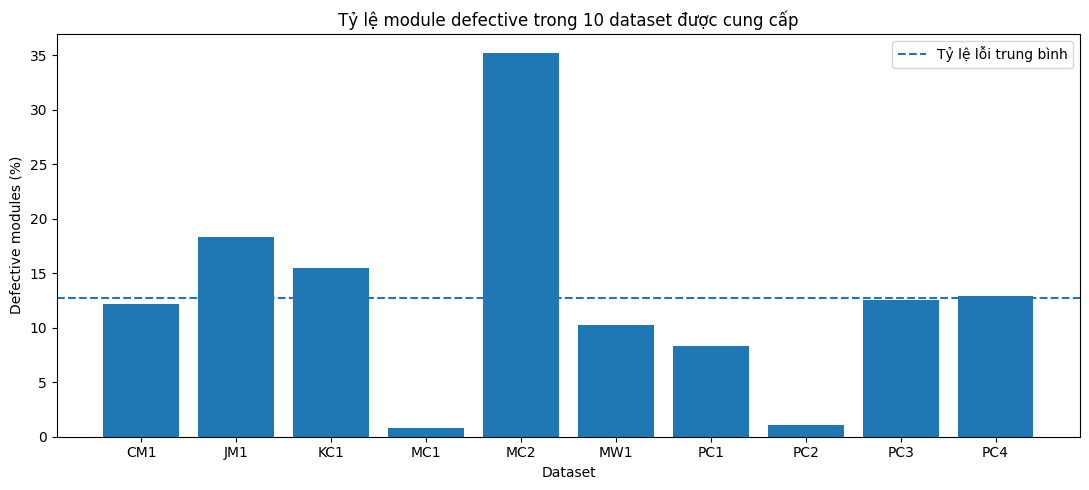

In [4]:
plt.figure(figsize=(11, 5))
plt.bar(summary_df["Dataset"], summary_df["Defect Ratio (%)"])
plt.axhline(summary_df["Defect Ratio (%)"].mean(), linestyle="--",
            label="Tỷ lệ lỗi trung bình")
plt.title("Tỷ lệ module defective trong 10 dataset được cung cấp")
plt.xlabel("Dataset")
plt.ylabel("Defective modules (%)")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_dataset_imbalance.png", dpi=180)
plt.show()

## 3. Thước đo đánh giá

Các metric chính là:

- **Accuracy**: tỷ lệ dự đoán đúng.
- **Precision, Recall, F-score**: tính với `average="weighted"` để xét sự mất cân bằng giữa hai lớp.
- **ROC-AUC**: mức phân biệt hai lớp từ xác suất hoặc decision score.

Bổ sung:

- **Recall defective** và **F1 defective** cho lớp dương (`defective = 1`).
- **PF** (Probability of False Alarm): `FP / (FP + TN)`.
- **G-measure**: trung bình điều hòa giữa Recall defective và Specificity.



## 4. Quy trình

Quy trình cho **mỗi dataset** và **mỗi fold**:

1. Chia dữ liệu bằng 10-fold stratified cross-validation, có shuffle.
2. Fit `SimpleImputer(strategy="median")` trên **training fold**; transform train/test.
3. Fit `StandardScaler()` trên **training fold**; transform train/test.
4. Áp dụng `SMOTE` trên **training fold đã chuẩn hóa mà thôi**.
5. Huấn luyện 12 classifiers trên cùng training fold đã SMOTE.
6. Dự đoán trên test fold nguyên bản đã transform; tính metrics.
7. Lấy trung bình 10 folds cho mỗi tổ hợp dataset–classifier.



In [5]:
MODEL_ORDER = [
    "RF", "DS", "SVM", "LR",
    "AdaBoost-RF", "AdaBoost-DS", "AdaBoost-SVM", "AdaBoost-LR",
    "Bagging-RF", "Bagging-DS", "Bagging-SVM", "Bagging-LR",
]

def build_models(random_state=RANDOM_STATE):
    linear_svm = LinearSVC(
        random_state=random_state, dual=False, max_iter=3000, tol=1e-3
    )
    base = {
        "RF": RandomForestClassifier(
            n_estimators=RF_TREES, random_state=random_state, n_jobs=1
        ),
        "DS": DecisionTreeClassifier(random_state=random_state),
        "SVM": linear_svm,
        "LR": LogisticRegression(
            random_state=random_state, max_iter=3000, solver="liblinear"
        ),
    }
    ensemble_base = {
        "RF": RandomForestClassifier(
            n_estimators=RF_TREES_INSIDE_ENSEMBLE,
            random_state=random_state, n_jobs=1
        ),
        "DS": DecisionTreeClassifier(random_state=random_state),
        "SVM": clone(linear_svm),
        "LR": LogisticRegression(
            random_state=random_state, max_iter=3000, solver="liblinear"
        ),
    }

    models = dict(base)
    models.update({
        f"AdaBoost-{key}": AdaBoostClassifier(
            estimator=clone(est), n_estimators=ENSEMBLE_ESTIMATORS,
            random_state=random_state
        ) for key, est in ensemble_base.items()
    })
    models.update({
        f"Bagging-{key}": BaggingClassifier(
            estimator=clone(est), n_estimators=ENSEMBLE_ESTIMATORS,
            random_state=random_state, n_jobs=1
        ) for key, est in ensemble_base.items()
    })
    return {key: models[key] for key in MODEL_ORDER}

models = build_models()
assert list(models.keys()) == MODEL_ORDER
model_design = pd.DataFrame({
    "Group": ["Base learner"] * 4 + ["AdaBoost"] * 4 + ["Bagging"] * 4,
    "Classifier": MODEL_ORDER,
})
display(model_design)
print("Tổng số classifier:", len(models))

,Group,Classifier
0,Base learner,RF
1,Base learner,DS
2,Base learner,SVM
3,Base learner,LR
4,AdaBoost,AdaBoost-RF
5,AdaBoost,AdaBoost-DS
6,AdaBoost,AdaBoost-SVM
7,AdaBoost,AdaBoost-LR
8,Bagging,Bagging-RF
9,Bagging,Bagging-DS


Tổng số classifier: 12


In [6]:
def positive_scores(fitted_model, X_test):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X_test)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        score = fitted_model.decision_function(X_test)
        return score if np.ndim(score) == 1 else score[:, 1]
    return fitted_model.predict(X_test)

def metrics_for_fold(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall_defective = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    pf = fp / (fp + tn) if (fp + tn) else np.nan
    g_measure = (
        2 * recall_defective * specificity / (recall_defective + specificity)
        if (recall_defective + specificity) else 0.0
    )
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "Recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "F1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Precision_defective": precision_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "Recall_defective": recall_defective,
        "F1_defective": f1_score(
            y_true, y_pred, pos_label=1, zero_division=0
        ),
        "PF": pf,
        "Specificity": specificity,
        "G_measure": g_measure,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    }

def evaluate_dataset(dataset_name, X, y):
    splitter = StratifiedKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
    )
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        imputer = SimpleImputer(strategy="median")
        scaler = StandardScaler()
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
        X_train_scaled = scaler.fit_transform(X_train_imputed)
        X_test_scaled = scaler.transform(X_test_imputed)

        minority_train = int(y_train.value_counts().min())
        k_neighbors = min(5, minority_train - 1)
        sampler = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
        X_resampled, y_resampled = sampler.fit_resample(X_train_scaled, y_train)

        for model_name, model in build_models().items():
            fitted = clone(model).fit(X_resampled, y_resampled)
            y_pred = fitted.predict(X_test_scaled)
            y_score = positive_scores(fitted, X_test_scaled)
            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "Fold": fold,
                "Train Size": len(train_idx),
                "Test Size": len(test_idx),
                "Train Size after SMOTE": len(y_resampled),
            }
            row.update(metrics_for_fold(y_test, y_pred, y_score))
            fold_rows.append(row)

    return pd.DataFrame(fold_rows)

## 5. Chạy thực nghiệm

`10 datasets × 10 folds × 12 classifiers = 1,200` lần huấn luyện.  

In [7]:
start = perf_counter()
fold_frames = []

with threadpool_limits(limits=1):
    for dataset_name in sorted(datasets):
        dataset_start = perf_counter()
        fold_df = evaluate_dataset(
            dataset_name, datasets[dataset_name]["X"], datasets[dataset_name]["y"]
        )
        fold_frames.append(fold_df)
        print(f"{dataset_name}: hoàn tất {len(fold_df)} evaluations "
              f"trong {perf_counter() - dataset_start:.1f}s")

fold_results_df = pd.concat(fold_frames, ignore_index=True)

metric_columns = [
    "Accuracy", "Precision_weighted", "Recall_weighted", "F1_weighted",
    "ROC_AUC", "Precision_defective", "Recall_defective", "F1_defective",
    "PF", "Specificity", "G_measure"
]
results_df = (
    fold_results_df
    .groupby(["Dataset", "Model"], as_index=False)[metric_columns]
    .mean()
)

cm_totals = (
    fold_results_df.groupby(["Dataset", "Model"], as_index=False)[["TN", "FP", "FN", "TP"]]
    .sum()
)
results_df = results_df.merge(cm_totals, on=["Dataset", "Model"])

assert len(fold_results_df) == 10 * 10 * 12
assert len(results_df) == 10 * 12
assert results_df["ROC_AUC"].notna().all()

fold_results_df.to_csv(OUTPUT_DIR / "fold_level_results.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "mean_results_by_dataset_model.csv", index=False)

elapsed = perf_counter() - start
print(f"\nHoàn tất: {len(fold_results_df)} fold-model evaluations; "
      f"{len(results_df)} dòng tổng hợp; thời gian = {elapsed:.1f}s.")
display(results_df.head().round(4))

CM1: hoàn tất 120 evaluations trong 1.8s
JM1: hoàn tất 120 evaluations trong 29.6s
KC1: hoàn tất 120 evaluations trong 5.1s
MC1: hoàn tất 120 evaluations trong 32.6s
MC2: hoàn tất 120 evaluations trong 1.4s
MW1: hoàn tất 120 evaluations trong 1.9s
PC1: hoàn tất 120 evaluations trong 3.6s
PC2: hoàn tất 120 evaluations trong 6.1s
PC3: hoàn tất 120 evaluations trong 5.5s
PC4: hoàn tất 120 evaluations trong 5.8s

Hoàn tất: 1200 fold-model evaluations; 120 dòng tổng hợp; thời gian = 93.3s.


,Dataset,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Precision_defective,Recall_defective,F1_defective,PF,Specificity,G_measure,TN,FP,FN,TP
0,CM1,AdaBoost-DS,0.8055,0.8389,0.8055,0.8176,0.6403,0.3148,0.420,0.3467,0.1395,0.8605,0.5167,260,42,25,17
1,CM1,AdaBoost-LR,0.7325,0.8756,0.7325,0.7757,0.7814,0.2826,0.770,0.4109,0.2716,0.7284,0.7357,220,82,10,32
2,CM1,AdaBoost-RF,0.7876,0.8148,0.7876,0.7991,0.6405,0.2347,0.295,0.2567,0.1427,0.8573,0.3973,259,43,30,12
3,CM1,AdaBoost-SVM,0.6945,0.8537,0.6945,0.7444,0.7433,0.2415,0.670,0.3514,0.3014,0.6986,0.6709,211,91,14,28
4,CM1,Bagging-DS,0.8081,0.8253,0.8081,0.8139,0.6915,0.2791,0.315,0.2839,0.1229,0.8771,0.4249,265,37,29,13


## 6. Kết quả

- **Table 2-style:** Accuracy.
- **Table 3-style:** weighted F-score.
- **Table 4-style:** ROC-AUC.

In [8]:
def make_paper_style_table(metric):
    table = results_df.pivot(index="Dataset", columns="Model", values=metric)
    return table.reindex(columns=MODEL_ORDER).round(4)

accuracy_table = make_paper_style_table("Accuracy")
fscore_table = make_paper_style_table("F1_weighted")
auc_table = make_paper_style_table("ROC_AUC")

print("Table 2-style — Accuracy")
display(accuracy_table)
print("Table 3-style — Weighted F-score")
display(fscore_table)
print("Table 4-style — ROC-AUC")
display(auc_table)

accuracy_table.to_csv(OUTPUT_DIR / "table2_style_accuracy.csv")
fscore_table.to_csv(OUTPUT_DIR / "table3_style_weighted_fscore.csv")
auc_table.to_csv(OUTPUT_DIR / "table4_style_roc_auc.csv")

Table 2-style — Accuracy


Model,RF,DS,SVM,LR,AdaBoost-RF,AdaBoost-DS,AdaBoost-SVM,AdaBoost-LR,Bagging-RF,Bagging-DS,Bagging-SVM,Bagging-LR
Dataset,,,,,,,,,,,,
CM1,0.8226,0.7997,0.7498,0.7412,0.7876,0.8055,0.6945,0.7325,0.7847,0.8081,0.7528,0.7470
JM1,0.8065,0.7523,0.6901,0.6950,0.7834,0.7705,0.6863,0.6997,0.7874,0.7806,0.6889,0.6942
KC1,0.8344,0.8153,0.7174,0.7179,0.8181,0.8243,0.7227,0.7375,0.8172,0.8315,0.7260,0.7256
MC1,0.9923,0.9887,0.8733,0.8808,0.9906,0.9894,0.8334,0.8249,0.9916,0.9892,0.8736,0.8807
MC2,0.6962,0.6410,0.6474,0.6551,0.6737,0.6173,0.6385,0.6397,0.6808,0.7551,0.6724,0.6705
MW1,0.8520,0.8101,0.7298,0.7372,0.8742,0.8140,0.7487,0.6910,0.8442,0.8291,0.7410,0.7373
PC1,0.8992,0.8586,0.8108,0.8081,0.8939,0.8748,0.7673,0.7293,0.8884,0.8721,0.8149,0.8040
PC2,0.9806,0.9725,0.9209,0.8988,0.9826,0.9726,0.8104,0.8299,0.9806,0.9759,0.9183,0.8968
PC3,0.8471,0.7980,0.7452,0.7397,0.8471,0.8390,0.7061,0.7024,0.8108,0.8235,0.7406,0.7352


Table 3-style — Weighted F-score


Model,RF,DS,SVM,LR,AdaBoost-RF,AdaBoost-DS,AdaBoost-SVM,AdaBoost-LR,Bagging-RF,Bagging-DS,Bagging-SVM,Bagging-LR
Dataset,,,,,,,,,,,,
CM1,0.8219,0.8113,0.7847,0.7775,0.7991,0.8176,0.7444,0.7757,0.8001,0.8139,0.7872,0.7826
JM1,0.7994,0.7582,0.7202,0.7241,0.7848,0.7700,0.7175,0.7275,0.7889,0.7803,0.7192,0.7235
KC1,0.8349,0.8187,0.7536,0.7537,0.8226,0.8245,0.7574,0.7686,0.8244,0.8321,0.7604,0.7599
MC1,0.9921,0.9895,0.9253,0.9296,0.9908,0.9900,0.9019,0.8966,0.9918,0.9901,0.9255,0.9296
MC2,0.6829,0.6369,0.6389,0.6511,0.6665,0.6160,0.6366,0.6448,0.6684,0.7424,0.6641,0.6642
MW1,0.8486,0.8258,0.7746,0.7810,0.8721,0.8206,0.7924,0.7491,0.8483,0.8370,0.7836,0.7798
PC1,0.8982,0.8677,0.8459,0.8451,0.8964,0.8804,0.8156,0.7875,0.8903,0.8813,0.8492,0.8421
PC2,0.9805,0.9765,0.9498,0.9373,0.9815,0.9766,0.8849,0.8960,0.9820,0.9787,0.9482,0.9363
PC3,0.8513,0.8122,0.7831,0.7796,0.8513,0.8419,0.7537,0.7512,0.8252,0.8322,0.7789,0.7758


Table 4-style — ROC-AUC


Model,RF,DS,SVM,LR,AdaBoost-RF,AdaBoost-DS,AdaBoost-SVM,AdaBoost-LR,Bagging-RF,Bagging-DS,Bagging-SVM,Bagging-LR
Dataset,,,,,,,,,,,,
CM1,0.7472,0.6153,0.7347,0.7420,0.6405,0.6403,0.7433,0.7814,0.7344,0.6915,0.6847,0.7451
JM1,0.7561,0.5993,0.7043,0.7061,0.7088,0.6776,0.6961,0.6641,0.7537,0.7049,0.6577,0.7061
KC1,0.8213,0.6504,0.7999,0.8010,0.7489,0.7579,0.7324,0.7395,0.8162,0.7749,0.7291,0.8006
MC1,0.9251,0.7597,0.8954,0.9010,0.8177,0.8604,0.8991,0.9197,0.9340,0.8286,0.8520,0.9012
MC2,0.7218,0.6121,0.6737,0.7027,0.7425,0.5976,0.6671,0.7302,0.6726,0.7359,0.7131,0.7171
MW1,0.7254,0.6168,0.6399,0.6639,0.6594,0.6350,0.6645,0.7116,0.7357,0.6514,0.6360,0.6802
PC1,0.8471,0.6153,0.8399,0.8634,0.7643,0.7384,0.8445,0.8034,0.8529,0.7737,0.8044,0.8595
PC2,0.8877,0.5905,0.8410,0.8024,0.6849,0.5905,0.7938,0.8285,0.8587,0.6516,0.7776,0.8095
PC3,0.8454,0.6374,0.8117,0.8115,0.8158,0.7609,0.7774,0.7753,0.8292,0.7767,0.7581,0.8086


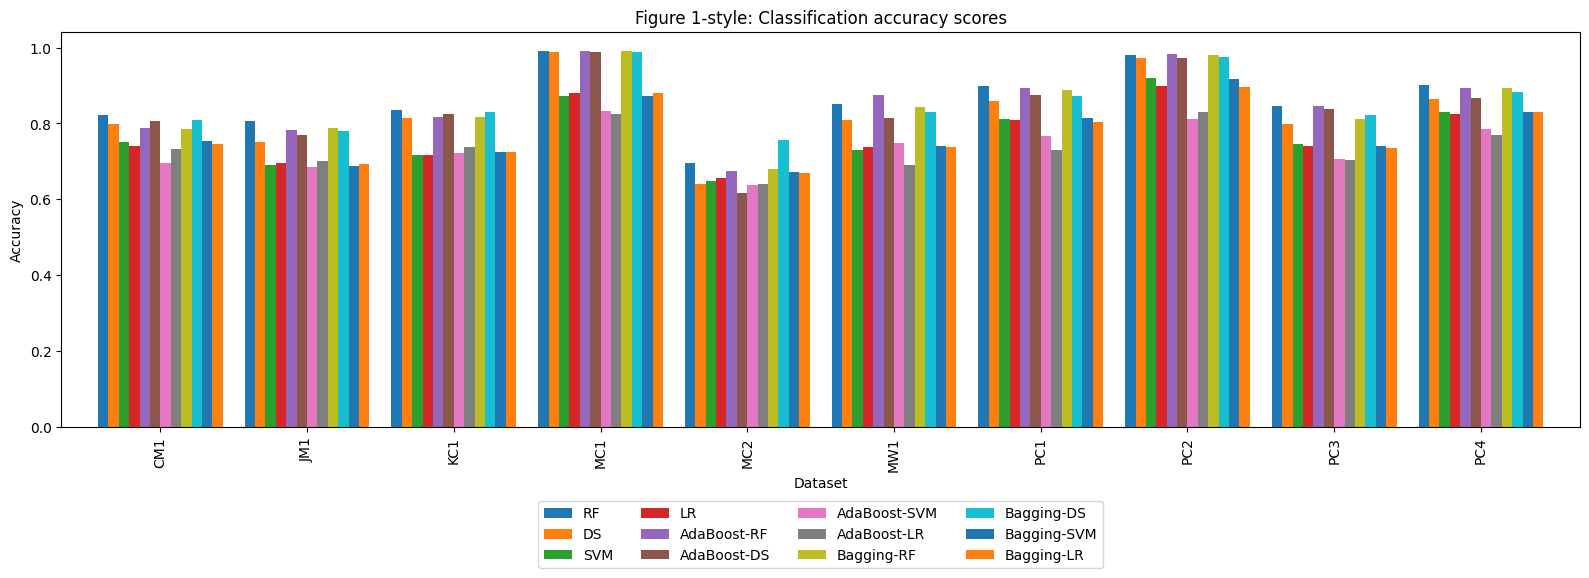

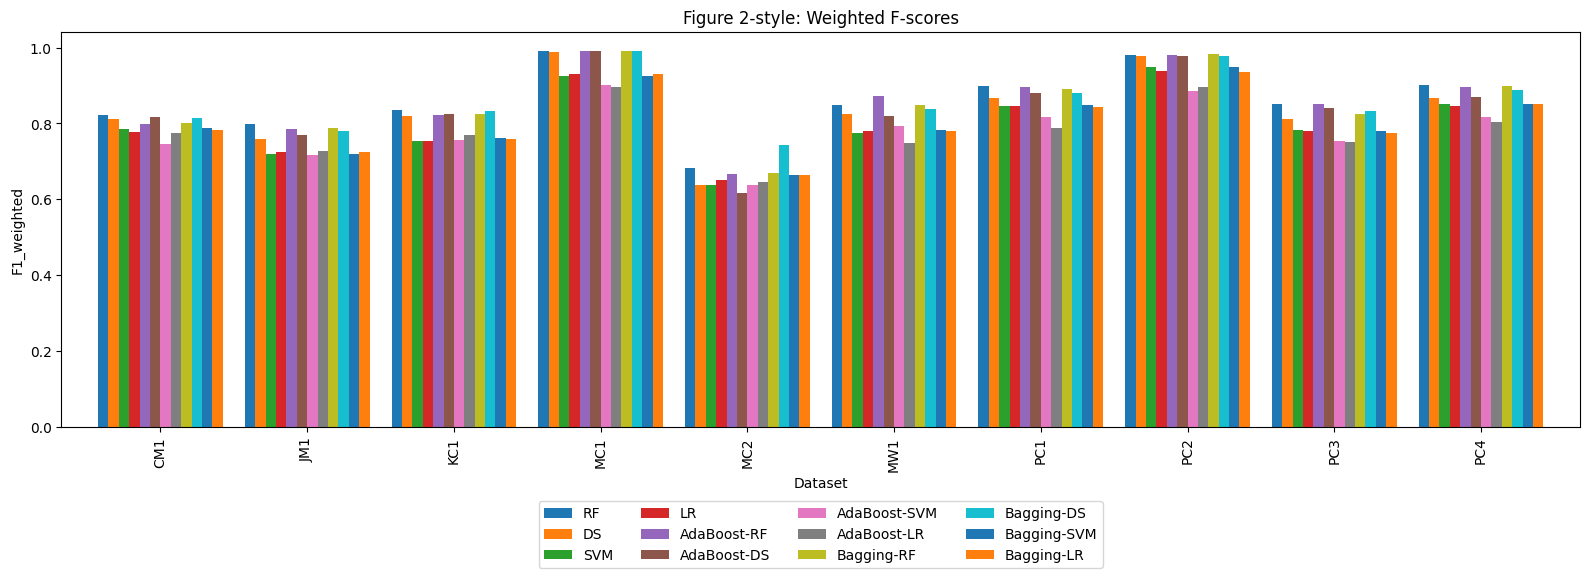

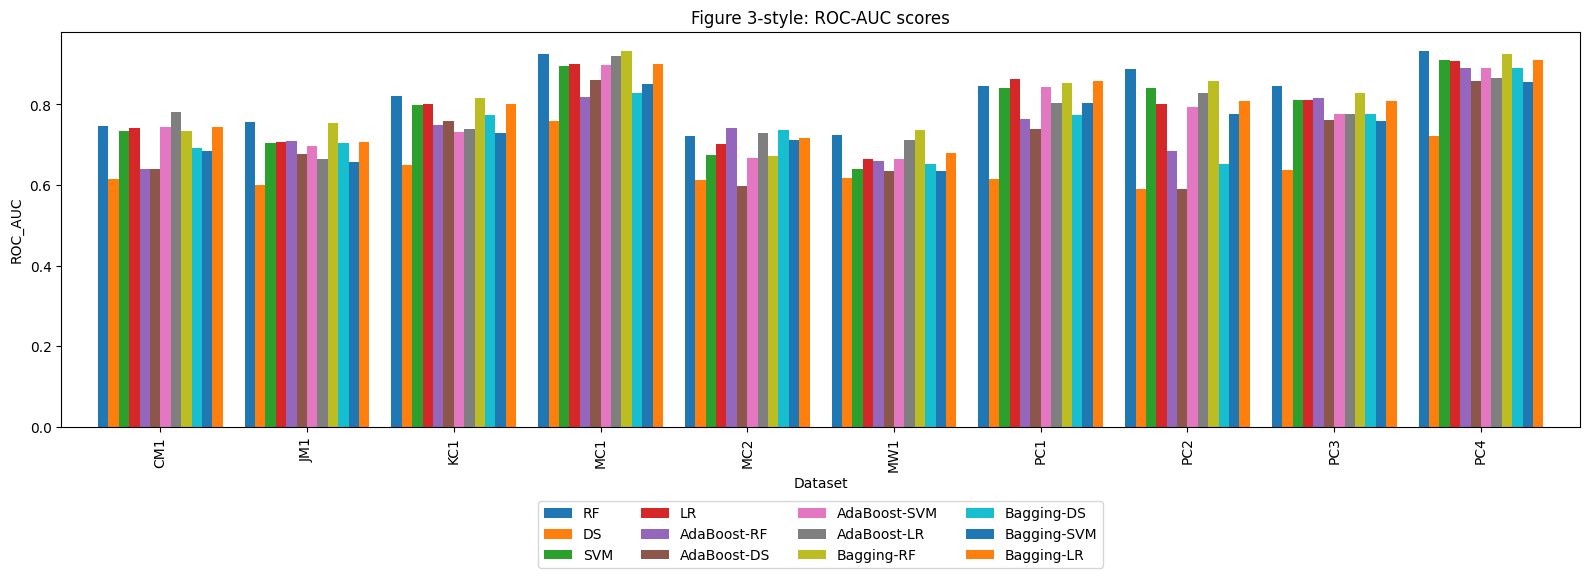

In [9]:
def plot_metric_by_dataset(metric, title, filename):
    table = results_df.pivot(index="Dataset", columns="Model", values=metric)
    table = table.reindex(columns=MODEL_ORDER)
    ax = table.plot(kind="bar", figsize=(16, 6), width=0.85)
    ax.set_title(title)
    ax.set_xlabel("Dataset")
    ax.set_ylabel(metric)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=4)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_metric_by_dataset(
    "Accuracy", "Figure 1-style: Classification accuracy scores", "figure1_accuracy.png"
)
plot_metric_by_dataset(
    "F1_weighted", "Figure 2-style: Weighted F-scores", "figure2_fscore.png"
)
plot_metric_by_dataset(
    "ROC_AUC", "Figure 3-style: ROC-AUC scores", "figure3_auc.png"
)

In [10]:
def winner_table(metric):
    best = results_df.groupby("Dataset")[metric].transform("max")
    winners = results_df[np.isclose(results_df[metric], best)].copy()
    return (
        winners.groupby("Dataset", as_index=False)
        .agg(Best_Model=("Model", lambda x: ", ".join(x)),
             Best_Score=(metric, "max"))
        .sort_values("Dataset")
    )

best_accuracy = winner_table("Accuracy")
best_fscore = winner_table("F1_weighted")
best_auc = winner_table("ROC_AUC")
best_defect_recall = winner_table("Recall_defective")

print("Mô hình tốt nhất theo Accuracy")
display(best_accuracy.round(4))
print("Mô hình tốt nhất theo weighted F-score")
display(best_fscore.round(4))
print("Mô hình tốt nhất theo ROC-AUC")
display(best_auc.round(4))
print("Phân tích bổ sung — mô hình tốt nhất theo Recall của lớp defective")
display(best_defect_recall.round(4))

best_accuracy.to_csv(OUTPUT_DIR / "best_model_by_accuracy.csv", index=False)
best_fscore.to_csv(OUTPUT_DIR / "best_model_by_weighted_fscore.csv", index=False)
best_auc.to_csv(OUTPUT_DIR / "best_model_by_roc_auc.csv", index=False)

Mô hình tốt nhất theo Accuracy


,Dataset,Best_Model,Best_Score
0,CM1,RF,0.8226
1,JM1,RF,0.8065
2,KC1,RF,0.8344
3,MC1,RF,0.9923
4,MC2,Bagging-DS,0.7551
5,MW1,AdaBoost-RF,0.8742
6,PC1,RF,0.8992
7,PC2,AdaBoost-RF,0.9826
8,PC3,"AdaBoost-RF, RF",0.8471
9,PC4,RF,0.9014


Mô hình tốt nhất theo weighted F-score


,Dataset,Best_Model,Best_Score
0,CM1,RF,0.8219
1,JM1,RF,0.7994
2,KC1,RF,0.8349
3,MC1,RF,0.9921
4,MC2,Bagging-DS,0.7424
5,MW1,AdaBoost-RF,0.8721
6,PC1,RF,0.8982
7,PC2,Bagging-RF,0.9820
8,PC3,RF,0.8513
9,PC4,RF,0.9024


Mô hình tốt nhất theo ROC-AUC


,Dataset,Best_Model,Best_Score
0,CM1,AdaBoost-LR,0.7814
1,JM1,RF,0.7561
2,KC1,RF,0.8213
3,MC1,Bagging-RF,0.9340
4,MC2,AdaBoost-RF,0.7425
5,MW1,Bagging-RF,0.7357
6,PC1,LR,0.8634
7,PC2,RF,0.8877
8,PC3,RF,0.8454
9,PC4,RF,0.9325


Phân tích bổ sung — mô hình tốt nhất theo Recall của lớp defective


,Dataset,Best_Model,Best_Score
0,CM1,AdaBoost-LR,0.7700
1,JM1,AdaBoost-SVM,0.6038
2,KC1,SVM,0.7322
3,MC1,"AdaBoost-SVM, Bagging-SVM, SVM",0.8095
4,MC2,AdaBoost-LR,0.6850
5,MW1,AdaBoost-LR,0.7167
6,PC1,AdaBoost-LR,0.8024
7,PC2,"AdaBoost-SVM, Bagging-LR",0.6000
8,PC3,AdaBoost-LR,0.7736
9,PC4,AdaBoost-SVM,0.8542


Trung bình các metric trên 10 dataset (xếp theo weighted F-score):


,Model,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,ROC_AUC,Precision_defective,Recall_defective,F1_defective,PF,Specificity,G_measure
10,RF,0.8632,0.8629,0.8632,0.8612,0.8210,0.4129,0.4040,0.3986,0.0798,0.9202,0.5176
4,Bagging-DS,0.8548,0.8660,0.8548,0.8576,0.7481,0.3798,0.4372,0.3939,0.0935,0.9065,0.5494
2,AdaBoost-RF,0.8545,0.8626,0.8545,0.8562,0.7474,0.3921,0.4225,0.3965,0.0952,0.9048,0.5326
6,Bagging-RF,0.8479,0.8607,0.8479,0.8518,0.8114,0.3931,0.4614,0.4118,0.1039,0.8961,0.5646
0,AdaBoost-DS,0.8375,0.8476,0.8375,0.8408,0.7118,0.3309,0.3975,0.3539,0.1127,0.8873,0.5043
8,DS,0.8300,0.8467,0.8300,0.8363,0.6418,0.3150,0.4029,0.3460,0.1213,0.8787,0.5130
7,Bagging-SVM,0.7759,0.8674,0.7759,0.8067,0.7468,0.2816,0.6476,0.3613,0.2083,0.7917,0.6766
5,Bagging-LR,0.7722,0.8666,0.7722,0.8044,0.7938,0.2769,0.6576,0.3575,0.2112,0.7888,0.6855
11,SVM,0.7716,0.8666,0.7716,0.8028,0.7851,0.2793,0.6541,0.3591,0.2137,0.7863,0.6847
9,LR,0.7699,0.8669,0.7699,0.8026,0.7902,0.2752,0.6603,0.3585,0.2174,0.7826,0.6832


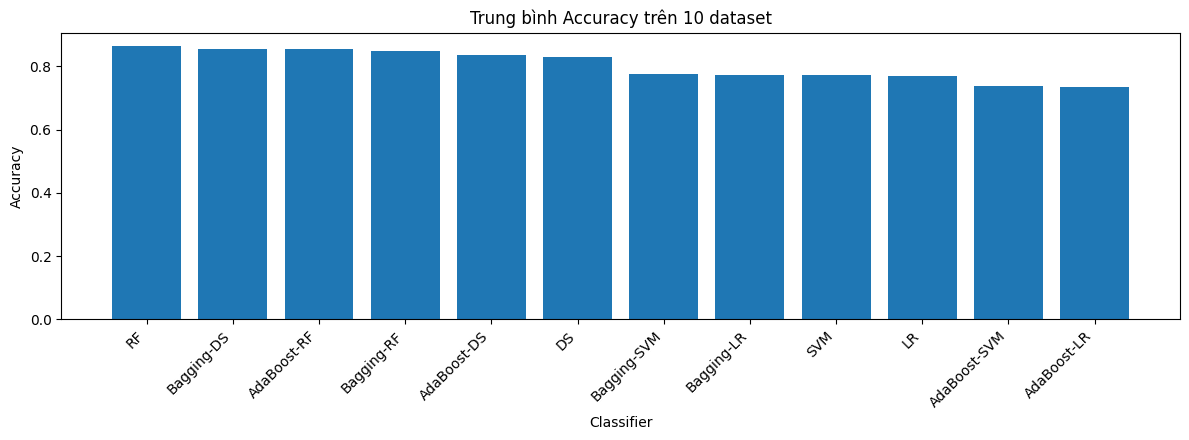

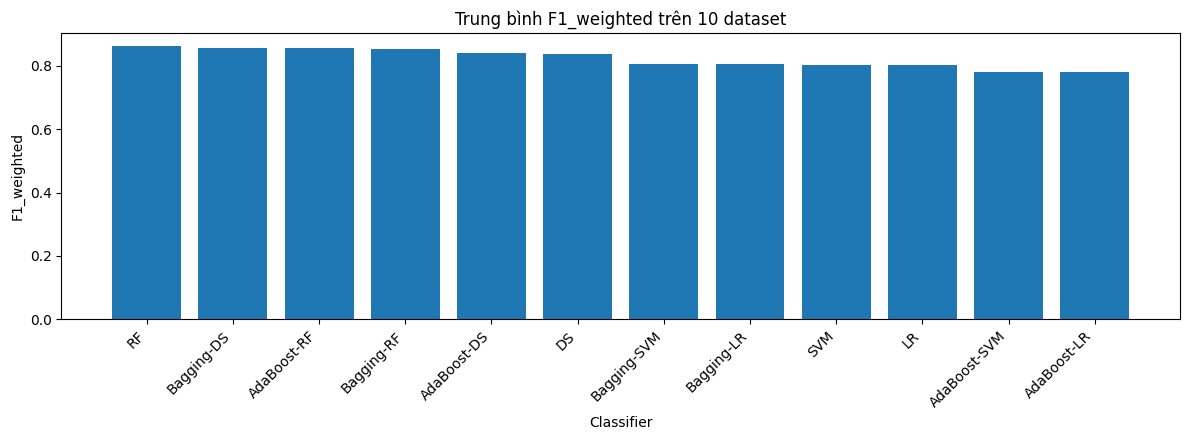

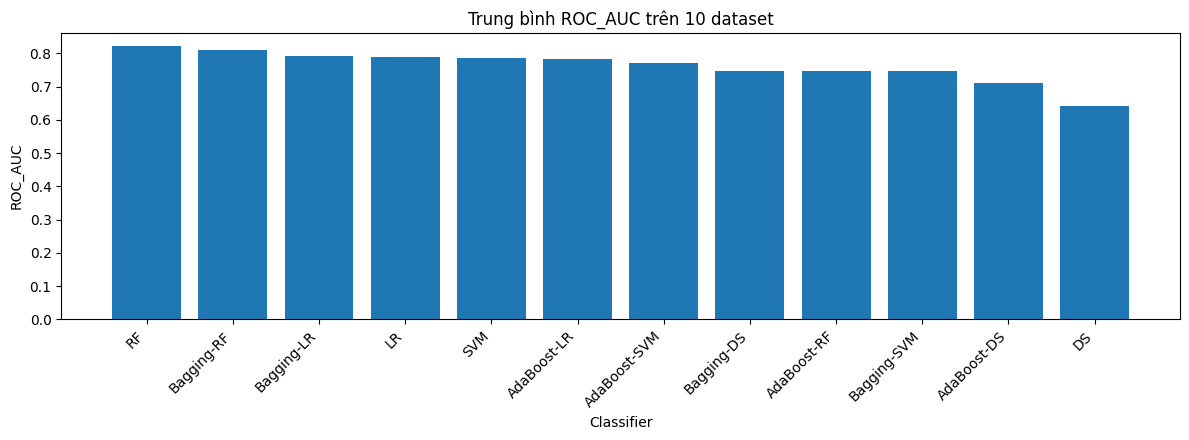

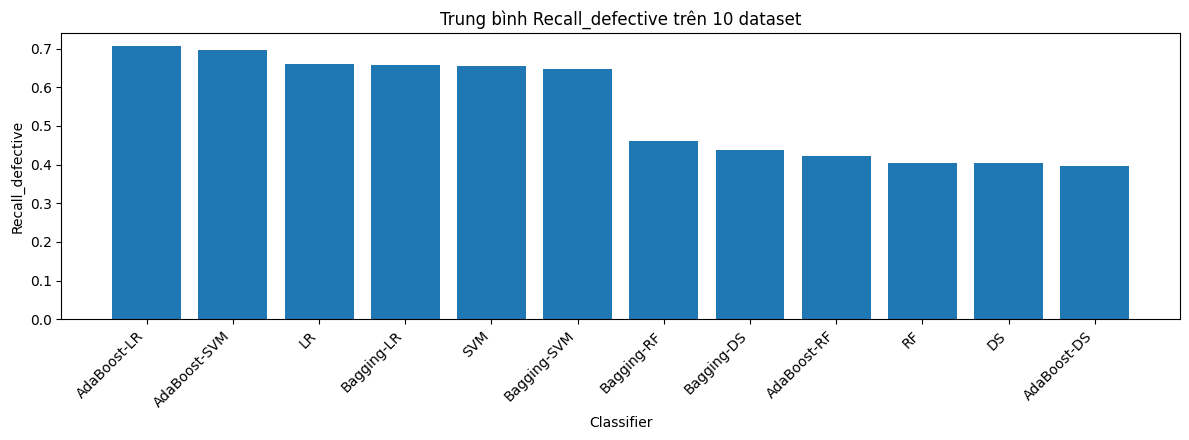

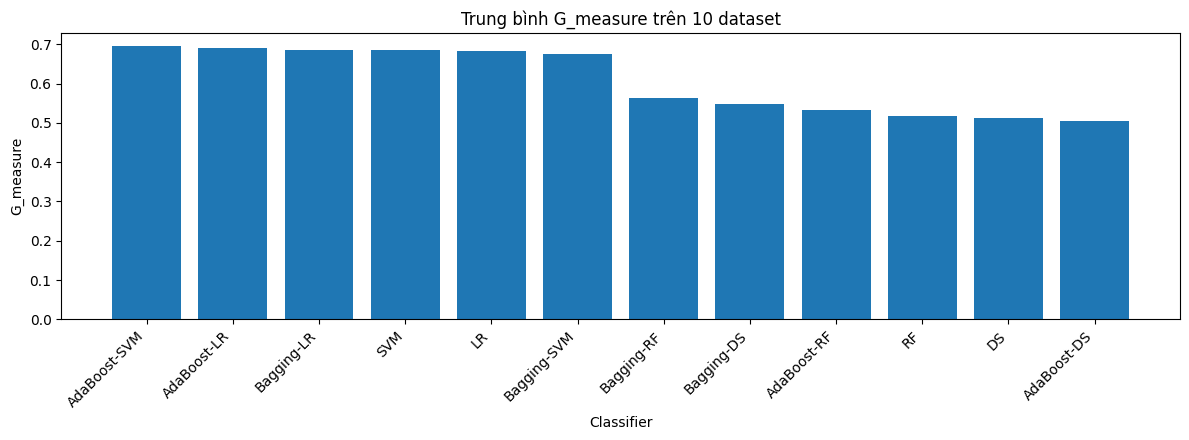

In [11]:
model_average = (
    results_df.groupby("Model", as_index=False)[metric_columns]
    .mean()
    .sort_values("F1_weighted", ascending=False)
)
print("Trung bình các metric trên 10 dataset (xếp theo weighted F-score):")
display(model_average.round(4))

for metric in ["Accuracy", "F1_weighted", "ROC_AUC", "Recall_defective", "G_measure"]:
    ordered = model_average.sort_values(metric, ascending=False)
    plt.figure(figsize=(12, 4.5))
    plt.bar(ordered["Model"], ordered[metric])
    plt.title(f"Trung bình {metric} trên 10 dataset")
    plt.xlabel("Classifier")
    plt.ylabel(metric)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"average_{metric.lower()}.png", dpi=180)
    plt.show()

model_average.to_csv(OUTPUT_DIR / "mean_results_by_model.csv", index=False)

## 7. Đối chiếu định tính với kết quả công bố

In [12]:
best_overall_f1 = model_average.iloc[0]
best_overall_auc = model_average.sort_values("ROC_AUC", ascending=False).iloc[0]
best_overall_recall = model_average.sort_values("Recall_defective", ascending=False).iloc[0]

paper_family = {"RF", "AdaBoost-RF", "Bagging-DS"}
fscore_paper_family_wins = sum(
    any(model.strip() in paper_family for model in winners.split(","))
    for winners in best_fscore["Best_Model"]
)

summary_text = f'''
### Nhận xét

- Xét trung bình trên 10 dataset, classifier đứng đầu theo **weighted F-score** là
  **{best_overall_f1["Model"]}** với điểm **{best_overall_f1["F1_weighted"]:.4f}**.
- Classifier đứng đầu theo **ROC-AUC** trung bình là **{best_overall_auc["Model"]}**
  với điểm **{best_overall_auc["ROC_AUC"]:.4f}**.
- Xét mục tiêu phát hiện module lỗi, classifier có **Recall defective** trung bình cao nhất là
  **{best_overall_recall["Model"]}** với điểm **{best_overall_recall["Recall_defective"]:.4f}**.
- Nhóm mô hình được bài báo kết luận là mạnh (`RF`, `AdaBoost-RF`, `Bagging-DS`) chiến thắng
  theo weighted F-score trên **{fscore_paper_family_wins}/10** dataset trong lần chạy này.

Khi weighted F-score cao nhưng Recall defective thấp, mô hình vẫn có thể bỏ sót nhiều module lỗi.
Vì vậy, kết luận kỹ thuật nên đọc đồng thời weighted F-score, ROC-AUC và Recall defective.
'''
display(Markdown(summary_text))


### Nhận xét

- Xét trung bình trên 10 dataset, classifier đứng đầu theo **weighted F-score** là
  **RF** với điểm **0.8612**.
- Classifier đứng đầu theo **ROC-AUC** trung bình là **RF**
  với điểm **0.8210**.
- Xét mục tiêu phát hiện module lỗi, classifier có **Recall defective** trung bình cao nhất là
  **AdaBoost-LR** với điểm **0.7054**.
- Nhóm mô hình được bài báo kết luận là mạnh (`RF`, `AdaBoost-RF`, `Bagging-DS`) chiến thắng
  theo weighted F-score trên **9/10** dataset trong lần chạy này.

Khi weighted F-score cao nhưng Recall defective thấp, mô hình vẫn có thể bỏ sót nhiều module lỗi.
Vì vậy, kết luận kỹ thuật nên đọc đồng thời weighted F-score, ROC-AUC và Recall defective.
